In [27]:
"""满足一定尺寸分布的粒子的散射特性"""
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import sys
sys.path.append("..")
from layer.particle_utils import extinction_efficiency, scattering_efficiency, single_scattering_albedo
from layer.particle_utils import scattering_cross_section_rayleigh_sphere, absorption_cross_section_rayleigh_sphere

In [28]:
def Qs_D(D, Lambda, epsr):
    """Scattering cross section of the particles"""
    Chis = np.pi * D / Lambda
    # Qs = np.zeros(len(Chis))
    # for i, Chi in enumerate(Chis):
        # Qs[i] = scattering_cross_section_rayleigh_sphere(Lambda, epsr, Chi)
    Qs = scattering_cross_section_rayleigh_sphere(Lambda, epsr, Chis)
    
    return Qs


def Qa_D(D, Lambda, epsr):
    Chis = np.pi * D / Lambda
    # Qs = np.zeros(len(Chis))
    # for i, Chi in enumerate(Chis):
        # Qs[i] = scattering_cross_section_rayleigh_sphere(Lambda, epsr, Chi)
    Qa = absorption_cross_section_rayleigh_sphere(Lambda, epsr, Chis)
    
    return Qa

In [22]:
def lunar_psd(D, k):
    """Lunar particle size distribution"""
    P = 0.5 # lunar porosity
    # Li and Wu, 2018, JGR, "Analysis of Rock Abundance on Lunar Surface From Orbital and Descent Images Using Automatic Rock Detection"
    A = 0.5648
    B = 0.01285
    q = A + B / k
    c = 6 * q * k / (np.pi * (1 - P))
    psd = c * np.exp(-3*np.log(D)-q*D)
    # psd[D==0] = 0.0

    return psd

In [50]:
epsr = 8-0.5j
f = 2.38e9
Lambda = 3e8 / f
Chis = np.logspace(-4, 0, 50)   # normalized circumference
D = Lambda * Chis / np.pi
k = 0.0000001

lunar_psd_int = lambda D: lunar_psd(D, k)
Qs_D_int = lambda D: Qs_D(D, Lambda, epsr)
Qa_D_int = lambda D: Qa_D(D, Lambda, epsr)

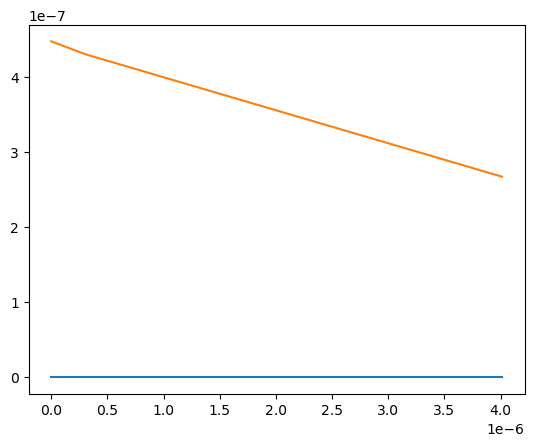

In [51]:
fun_int = lambda D: lunar_psd_int(D) * Qs_D_int(D)
fun_int_a = lambda D: lunar_psd_int(D) * Qa_D_int(D)


# 看ks, ka随积分下限的变化
Dmins = np.logspace(-10, 0, 10) * D[0]
kss = np.zeros(len(Dmins))
kas = np.zeros(len(Dmins))
for i in range(len(Dmins)):
    kss[i], err = quad(fun_int, Dmins[i], D[-1])
    kas[i], err = quad(fun_int_a, Dmins[i], D[-1])
# print(f"ks: {ks}, ka:{ka}")

plt.plot(Dmins, kss, label='ks')
plt.plot(Dmins, kas, label='ka')

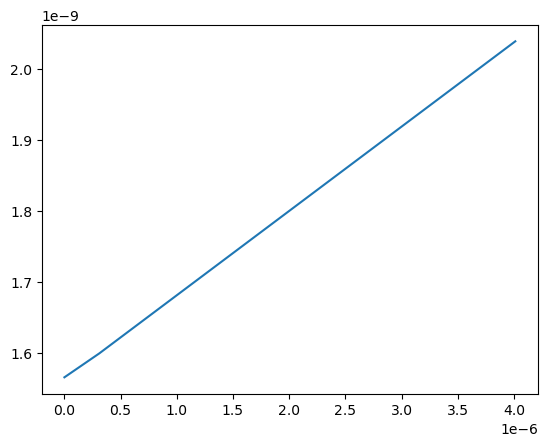

In [52]:
ssa = kss/(kss+kas)
ssa[0]
plt.plot(Dmins, kss/(kss+kas), label='a')

1.5650257242651946e-09

In [54]:
kas[0]

4.4750067921492114e-07

In [37]:
kas[-1]

0.003200743768493171

In [32]:
D[0]

4.012309489711647e-06

In [25]:
r

0.017128608872277393

In [26]:
err

1.90165759498011e-16

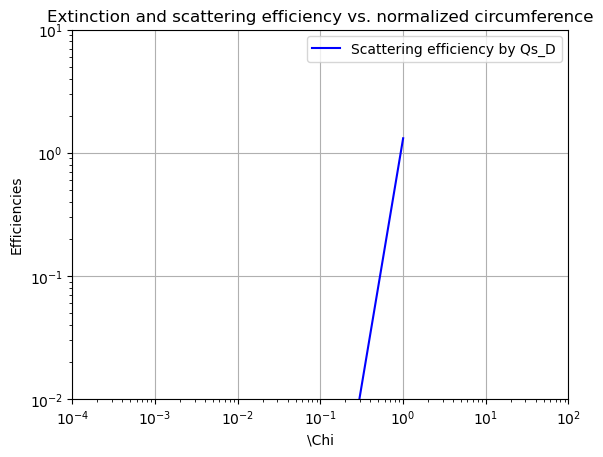

In [12]:
# Ulaby2014, Fig8-19, p345
epsr = 8-0.5j
f = 2.38e9
Lambda = 3e8 / f
Chis = np.logspace(-4, 0, 50)   # normalized circumference
D = Lambda * Chis / np.pi

Qs = Qs_D(D,Lambda, epsr)
A = np.pi * (D/2)**2
sca_effs1 = Qs / A

plt.loglog(Chis, sca_effs1, 'b-', label='Scattering efficiency by Qs_D')
plt.xlabel('\Chi')
plt.ylabel('Efficiencies')
plt.legend()
plt.xlim(1e-4, 100)
plt.ylim(0.01, 10)
plt.grid()
plt.title('Extinction and scattering efficiency vs. normalized circumference')
plt.show()

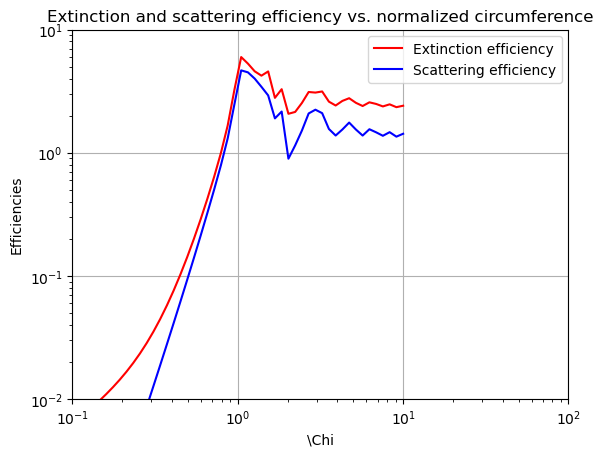

In [8]:
# Ulaby2014, Fig8-19, p345
epsr = 8-0.5j
Chis = np.logspace(-1, 1, 50)   # normalized circumference
Num = len(Chis)
ext_effs = np.zeros(Num)
sca_effs = np.zeros(Num)
for i in range(Num):
    ext_effs[i] = extinction_efficiency(epsr, Chis[i])
    sca_effs[i] = scattering_efficiency(epsr, Chis[i])
plt.loglog(Chis, ext_effs, 'r-', label='Extinction efficiency')
plt.loglog(Chis, sca_effs, 'b-', label='Scattering efficiency')
plt.xlabel('\Chi')
plt.ylabel('Efficiencies')
plt.legend()
plt.xlim(0.1, 100)
plt.ylim(0.01, 10)
plt.grid()
plt.title('Extinction and scattering efficiency vs. normalized circumference')
plt.show()

In [7]:
# epsr = 3.2 - 3.2j
# Chis = np.logspace(-1, 1, 50)
# Num = len(Chis)
# ssas = np.zeros(Num)
# sca_effs = np.zeros(Num)
# for i in range(Num):
#     ssas[i] = single_scattering_albedo(epsr, Chis[i])
# plt.loglog(Chis, ssas, 'r-', label='SSA')
# plt.xlabel('\Chi')
# plt.ylabel('SSA')
# plt.legend()
# plt.xlim(0.1, 100)
# plt.ylim(0.01, 10)
# plt.grid()
# plt.title('Single scattering albedo vs. normalized circumference')
# plt.show()

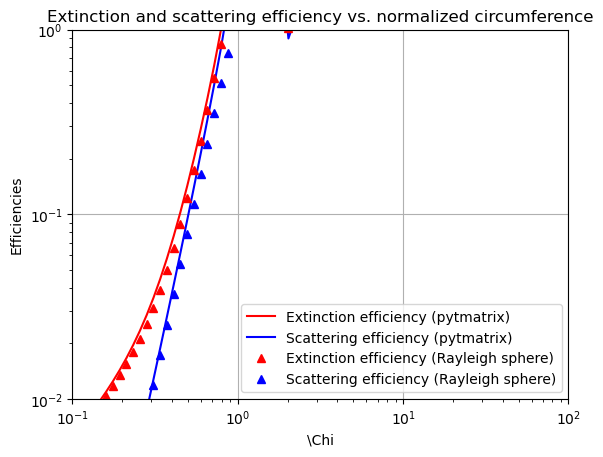

In [8]:
# Ulaby2014, Fig8-19, p345 / Compare T-matrix with Rayleigh sphere approximation
Lambda = 1
A = np.pi * (Chis * Lambda / (2* np.pi))**2
sca_effs2 = scattering_cross_section_rayleigh_sphere(Lambda, epsr, Chis) / A
a_effs = absorption_cross_section_rayleigh_sphere(Lambda, epsr, Chis) / A
ext_effs2 = sca_effs + a_effs

plt.loglog(Chis, ext_effs, 'r-', label='Extinction efficiency (pytmatrix)')
plt.loglog(Chis, sca_effs, 'b-', label='Scattering efficiency (pytmatrix)')
plt.loglog(Chis, ext_effs2, 'r^', label='Extinction efficiency (Rayleigh sphere)')
plt.loglog(Chis, sca_effs2, 'b^', label='Scattering efficiency (Rayleigh sphere)')
plt.xlabel('\Chi')
plt.ylabel('Efficiencies')
plt.legend()
plt.xlim(0.1, 100)
plt.ylim(0.01, 1)
plt.grid()
plt.title('Extinction and scattering efficiency vs. normalized circumference')
plt.show()